In [2]:
# the goal of this script is to analyze how the day of week of release impacts box office day
from database.db import supabase
import datetime as dt
import seaborn as sns   
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# get the top 150 movie ids
top_x_movies = supabase.rpc("topx", {"x": 300}).execute().data

print(top_x_movies)

[{'return_id': 'f28bf7a3-2097-46fe-9742-2f82c91dd317', 'title': 'Star Wars: The Force Awakens', 'total_revenue': 935642689}, {'return_id': '88d1658c-1f87-4c5a-91c5-ab754a142c9a', 'title': 'Avengers: Endgame', 'total_revenue': 858373000}, {'return_id': '4d73f482-121f-489a-ae1f-b2811d0f7c35', 'title': 'Spider-Man: No Way Home', 'total_revenue': 814804872}, {'return_id': 'd59218eb-83da-44c0-82db-09dd1755628d', 'title': 'Top Gun: Maverick', 'total_revenue': 718732821}, {'return_id': 'c28c27e7-9fa7-4364-b8ab-4fc1956d5a3e', 'title': 'Black Panther', 'total_revenue': 700059566}, {'return_id': '0dd49c55-8c04-48c8-a0c9-a615f1d68217', 'title': 'Avatar: The Way of Water', 'total_revenue': 684075767}, {'return_id': '059852d2-45ee-4f0b-a89a-019aff9b4ce0', 'title': 'Avengers: Infinity War', 'total_revenue': 678815482}, {'return_id': 'f9a04397-9d1a-4de4-86ef-fb469d008e50', 'title': 'Inside Out 2', 'total_revenue': 652980194}, {'return_id': '27c91bee-397e-413f-aa5f-f11184de9279', 'title': 'Jurassic Wo

In [4]:
# now get the first 28 box office days for each movie
days_to_get = 15

gotten_days = (
    supabase.rpc(
        "first_days_multi",
        {"movie_ids": [x["return_id"] for x in top_x_movies], "x": days_to_get},
    )
    .execute()
    .data
)

print(len(gotten_days))

print(gotten_days[0])

4500
{'return_id': 'f28bf7a3-2097-46fe-9742-2f82c91dd317', 'date': '2015-12-18', 'revenue': 119119282}


<Axes: >

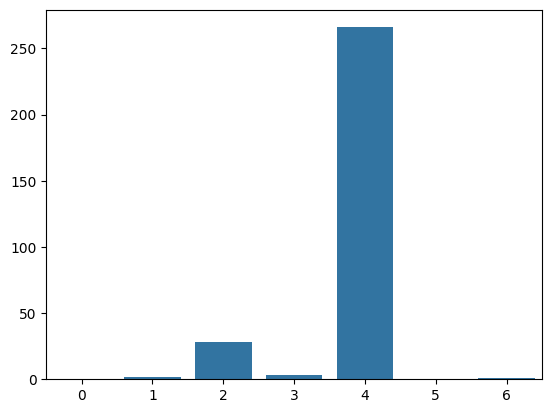

In [5]:
# figure out how frequently the movies are released on each day of the week
# 0 is Monday, 6 is Sunday
day_counts = [0] * 7

box_office_day_by_movie = {}

for day in gotten_days:
    if day["return_id"] not in box_office_day_by_movie:
        box_office_day_by_movie[day["return_id"]] = []
    box_office_day_by_movie[day["return_id"]].append(day)

for movie in box_office_day_by_movie:
    first_day = box_office_day_by_movie[movie][0]

    first_day_date = dt.datetime.strptime(first_day["date"], "%Y-%m-%d")
    day_counts[first_day_date.weekday()] += 1

sns.barplot(x=[x for x in range(7)], y=day_counts)

[0, 42526671.5, 20303104.67857143, 14548865.666666666, 49513053.477443606, 0, 838571.0]
[0, 2, 28, 3, 266, 0, 1]


<Axes: >

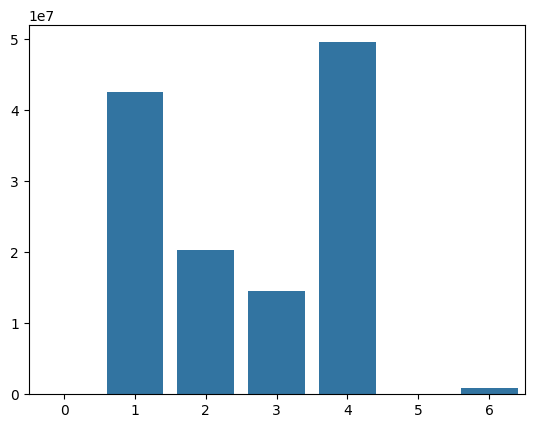

In [6]:
# get the sum of the first 2 days of box office for each movie and graph based on day of week
day_sums = [0] * 7

for movie in box_office_day_by_movie:
    first_day = box_office_day_by_movie[movie][0]
    second_day = box_office_day_by_movie[movie][1]

    first_day_date = dt.datetime.strptime(first_day["date"], "%Y-%m-%d")
    second_day_date = dt.datetime.strptime(second_day["date"], "%Y-%m-%d")

    day_sums[first_day_date.weekday()] += first_day["revenue"] + second_day["revenue"]

# divide the day sums by the number of movies released on that day
for i in range(7):
    if day_counts[i] > 0:
        day_sums[i] /= day_counts[i]

print(day_sums)
print(day_counts)

sns.barplot(x=[x for x in range(7)], y=day_sums)

In [7]:
# the main question to ask: how to adjust the friday and saturday numbers to account for movies that are released on a Tuesday, Wednesday, or Thursday?
# probably just ignore the initial multipliers until the first Monday -> Tuesday one if a movie doesn't open on a Friday, do better later

In [8]:
# plot the sum_by_day function

start_date = dt.date(2015, 1, 1)
end_date = dt.date(2025, 1, 1)
response = supabase.rpc(
    "sum_by_day",
    {"start_date": start_date.isoformat(), "end_date": end_date.isoformat(), "filter_x_days": 0},
).execute()

data = response.data

revenue_by_date: dict[dt.date, int] = {}
days_since_first_friday_in_year = [0] * (366 + 6)
theater_weighted_since_first_friday_in_year = [0] * (366 + 6)
all_days = [0] * 366

first_fridays_in_year: dict[int, int] = {}

# create first friday in year dictionary
for i in range(start_date.year, end_date.year + 1):
    date = dt.date(i, 1, 1)
    while date.weekday() != 4:
        date += dt.timedelta(days=1)
    first_fridays_in_year[i] = date.timetuple().tm_yday

for day in data:
    date = dt.datetime.strptime(day["date"], "%Y-%m-%d")
    day_of_week = date.weekday()

    days_since_first_friday_in_year[
        date.timetuple().tm_yday - first_fridays_in_year[date.year]
    ] += day["revenue"]
    # days_since_first_friday_in_year_counts[
    #     date.timetuple().tm_yday - first_fridays_in_year[date.year]
    # ] += 1

    theater_weighted_since_first_friday_in_year[
        date.timetuple().tm_yday - first_fridays_in_year[date.year]
    ] += day["theater_weighted_budget"]
    # theater_weighted_since_first_friday_in_year_counts[
    #     date.timetuple().tm_yday - first_fridays_in_year[date.year]
    # ] += 1

    all_days[date.timetuple().tm_yday - 1] += day["revenue"]

    revenue_by_date[date.date()] = day["revenue"]

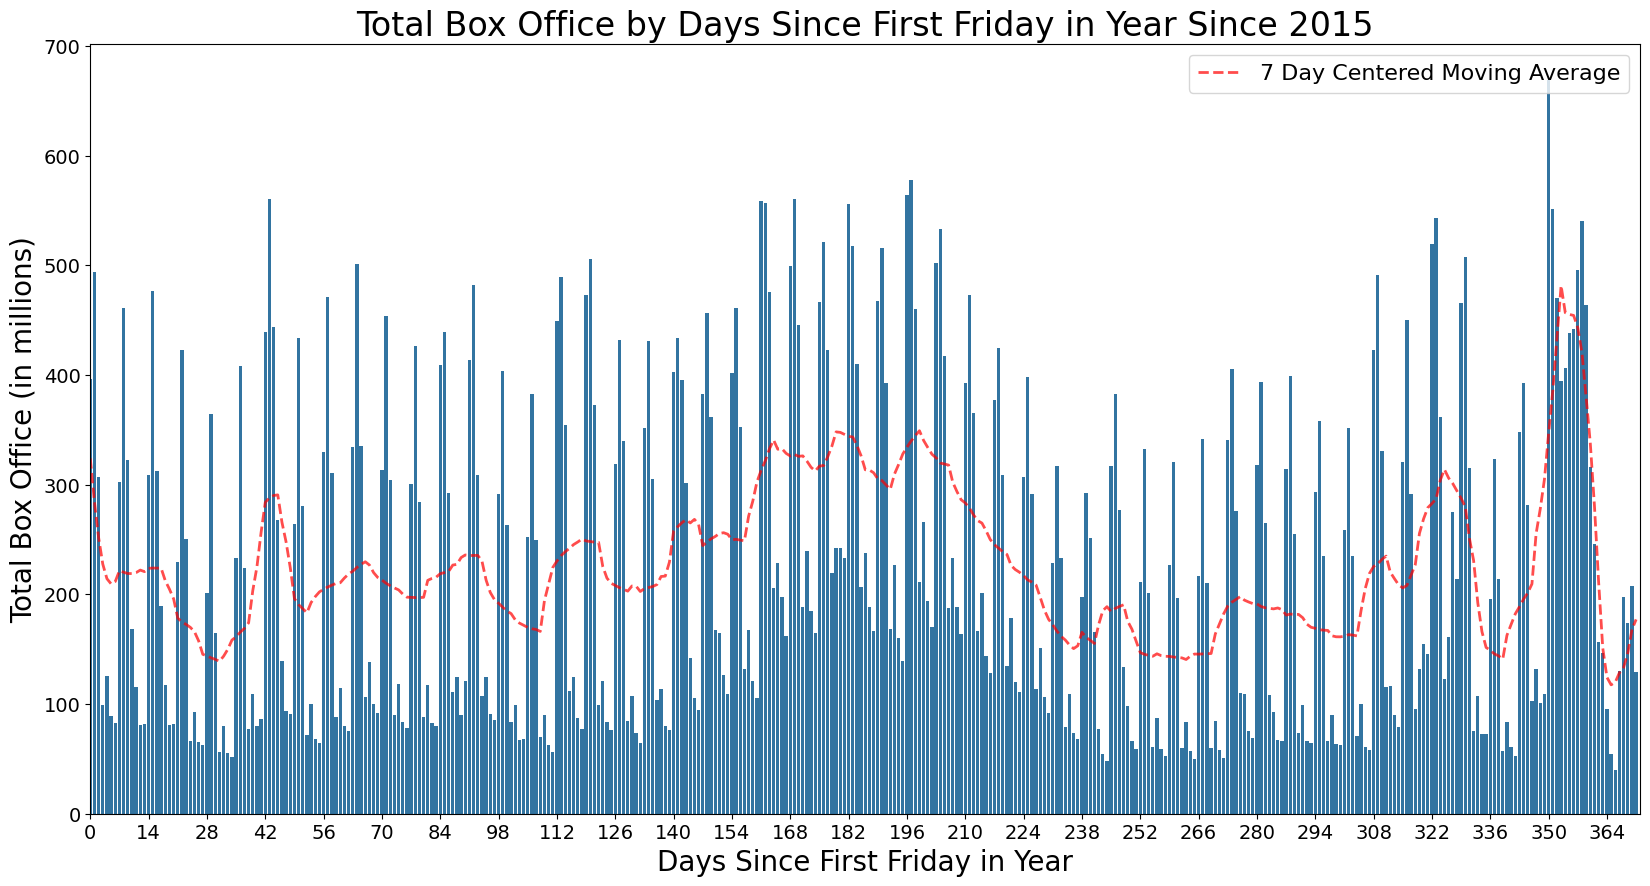

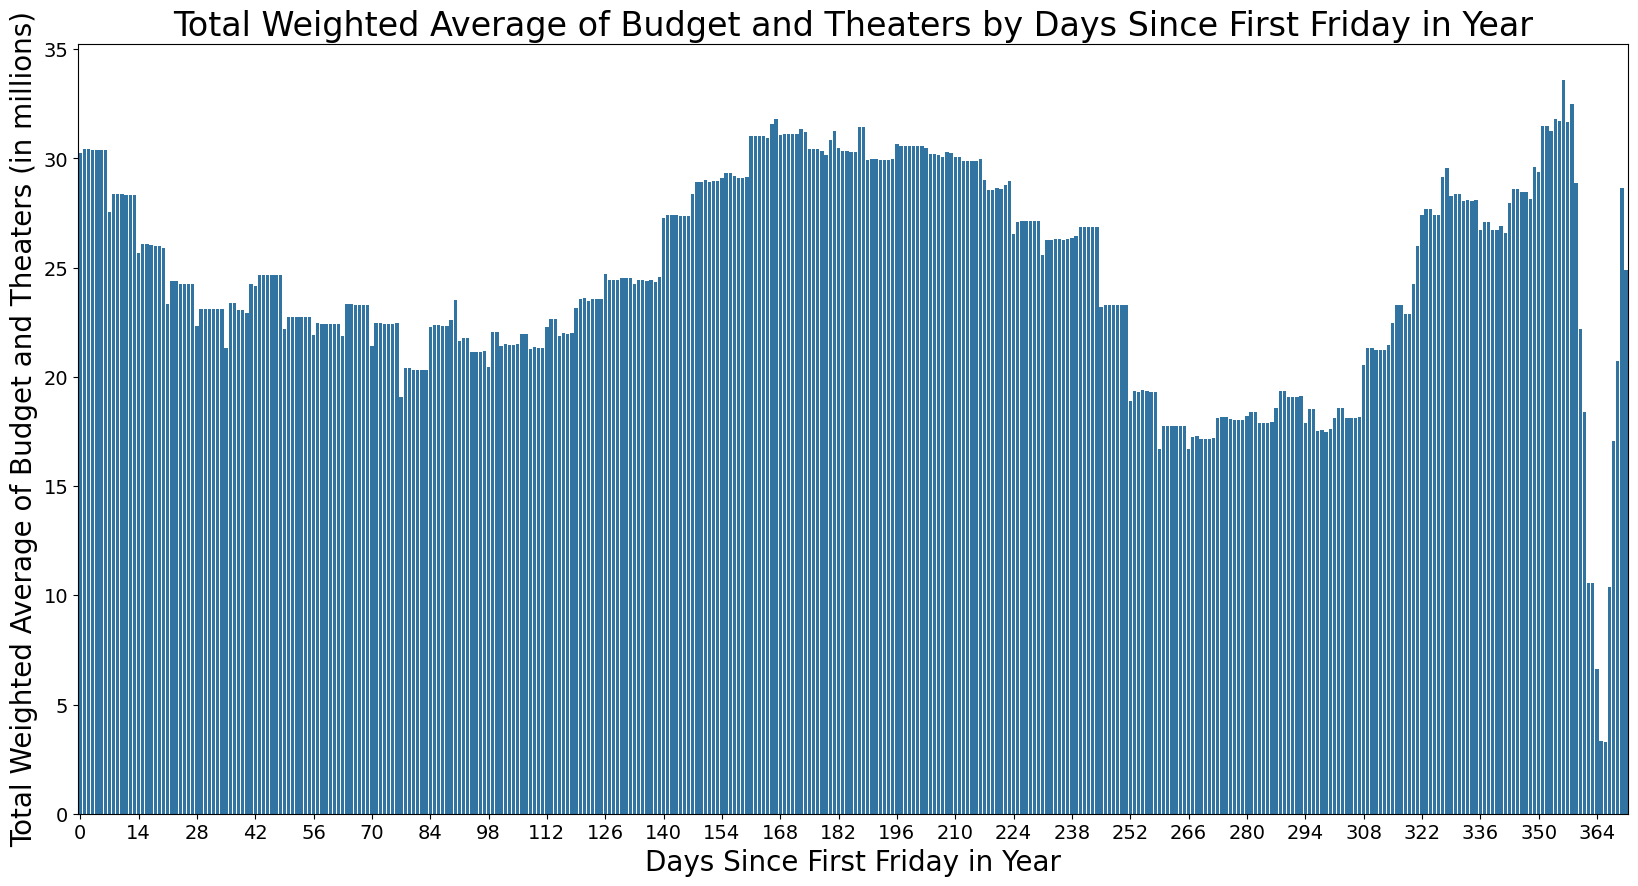

In [9]:
# now plot the data
plt.figure(figsize=(20, 10))
sns.barplot(x=[x for x in range(366 + 6)], y=[val / 1_000_000 for val in days_since_first_friday_in_year])
# add a 7 day trailing average to the data
moving_average_length = 7
moving_average = []
half_window = moving_average_length // 2

for i in range(len(days_since_first_friday_in_year)):
    start_idx = max(0, i - half_window)
    end_idx = min(len(days_since_first_friday_in_year), i + half_window + 1)
    moving_average.append(
        sum(days_since_first_friday_in_year[start_idx:end_idx]) / (end_idx - start_idx)
    )

# plt.plot([x for x in range(366 + 6)], [val / 1_000_000 for val in moving_average], color="red", label=f"{moving_average_length} Day Moving Average")
sns.lineplot(
    x=[x for x in range(366 + 6)],
    y=[val / 1_000_000 for val in moving_average],
    color="red",
    label=f"{moving_average_length} Day Centered Moving Average",
    linewidth=2,
    linestyle="--",
    alpha=0.7,
)
plt.legend(loc="upper right", fontsize=16)


plt.title("Total Box Office by Days Since First Friday in Year Since 2015", fontsize=24)
plt.xlabel("Days Since First Friday in Year", fontsize=20)
plt.ylabel("Total Box Office (in millions)", fontsize=20)

# only do every 7 labels on the x axis
plt.xticks([x for x in range(0, 366 + 6, 14)], fontsize=14)
plt.yticks(fontsize=14)

# get rid of extra space between y axis and graph
plt.gca().set_ylim(bottom=0)

# change the y axis to not be in scientific notation
plt.ticklabel_format(style="plain", axis="y")
plt.xlim(0, 366 + 6)

plt.show()

plt.figure(figsize=(20, 10))
sns.barplot(
    x=[x for x in range(366 + 6)], y=[val / 1_000_000 for val in theater_weighted_since_first_friday_in_year]
)


plt.title("Total Weighted Average of Budget and Theaters by Days Since First Friday in Year", fontsize=24)
plt.xlabel("Days Since First Friday in Year", fontsize=20)
plt.ylabel("Total Weighted Average of Budget and Theaters (in millions)", fontsize=20)
# only do every 7 labels on the x axis
plt.xticks([x for x in range(0, 366 + 6, 14)], fontsize=14)
plt.yticks(fontsize=14)
# change the y axis to not be in scientific notation
plt.ticklabel_format(style="plain", axis="y")
# plt.figure(figsize=(20, 10))
# sns.barplot(x=[x for x in range(366)], y=all_days)

In [10]:
from modeling.day_tags import get_day_tags, tag_data

# goal is to make a chart comparing holidays to the average of the 7 days prior and 7 days after

# loop through every day

holiday_dates: dict[dt.date, list[tuple[str, str]]] = (
    {}
)  # a tuple of the holiday string and whether it is before after or on the holiday

# loop through every day between 2015 and 2025

start_date = dt.date(2015, 1, 1)

while start_date < dt.date.today() - dt.timedelta(days=2):
    # get the day tags
    day_tags = get_day_tags(start_date, tag_data.day_tags_dict)

    for tag in day_tags:
        tag_str = tag.name

        if start_date not in holiday_dates:
            holiday_dates[start_date] = []
        holiday_dates[start_date].append((tag_str, tag_str))

        seven_days_prior = start_date - dt.timedelta(days=7)
        seven_days_after = start_date + dt.timedelta(days=7)
        if seven_days_prior not in holiday_dates:
            holiday_dates[seven_days_prior] = []
        holiday_dates[seven_days_prior].append((tag_str, "before"))
        if seven_days_after not in holiday_dates:
            holiday_dates[seven_days_after] = []
        holiday_dates[seven_days_after].append((tag_str, "after"))

    start_date += dt.timedelta(days=1)


holidays: dict[str, tuple[list[int], list[int]]] = (
    {}
)  # dict from holiday name to (grosses on day), (grosses a week prior and after)

for holiday in holiday_dates:
    holiday_str = holiday_dates[holiday][0][0]
    if holiday_str not in holidays:
        holidays[holiday_str] = ([], [])


    seven_days_prior = holiday - dt.timedelta(days=7)
    seven_days_after = holiday + dt.timedelta(days=7)

    if seven_days_prior not in revenue_by_date or seven_days_after not in revenue_by_date:
        continue

    holidays[holiday_str][0].append(revenue_by_date[holiday])
    holidays[holiday_str][1].append(revenue_by_date[seven_days_prior])
    holidays[holiday_str][1].append(revenue_by_date[seven_days_after])

Text(0, 0.5, 'Box Office Impact (percent difference from 7 days prior and after)')

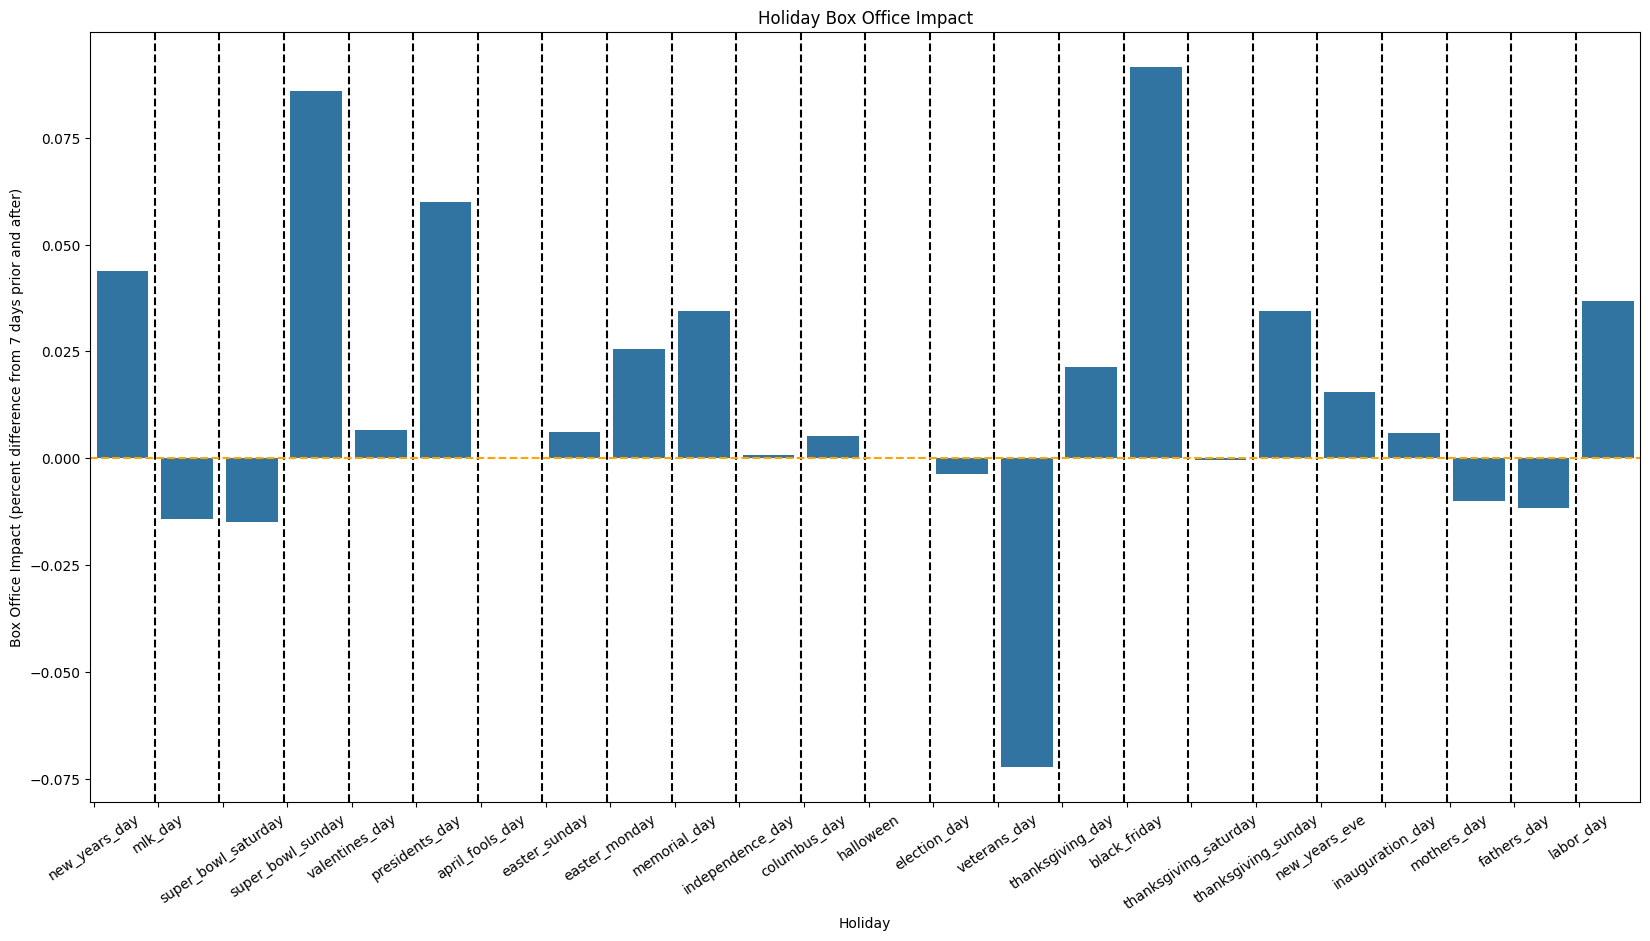

In [11]:
# now plot the data
import numpy as np
plt.figure(figsize=(20, 10))
sns.barplot(
    x=[x for x in range(len(holidays))],
    y=[(np.median(holidays[x][0]) - np.median(holidays[x][1])) / (np.median(holidays[x][1]) + np.median(holidays[x][0])) for x in holidays],
)

# label the x axis with the holiday names
plt.xticks(
    [x - 0.45 for x in range(len(holidays))], [x for x in holidays], rotation=34
)

# vertical lines between each holiday
for i in range(len(holidays) - 1):
    plt.axvline(x=i + 0.5, color="black", linestyle="--")

# horizontal line at 0
plt.axhline(y=0, color="orange", linestyle="--")

plt.title("Holiday Box Office Impact")

plt.xlabel("Holiday")
plt.ylabel("Box Office Impact (percent difference from 7 days prior and after)")

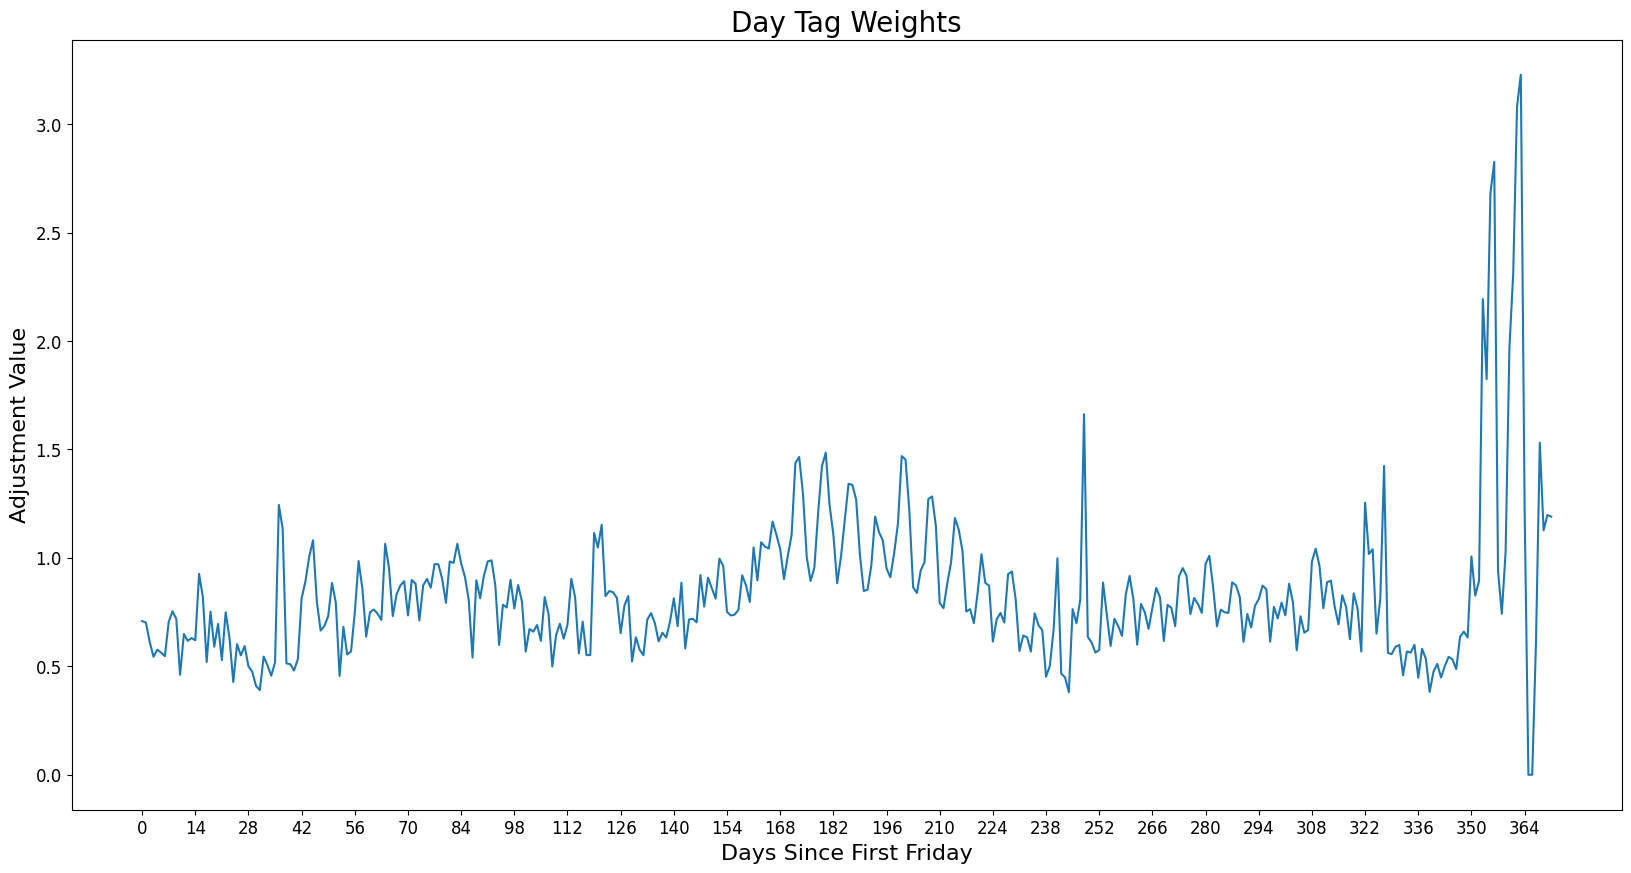

In [12]:
from modeling.day_tags import tag_weight_averages, days_since_first_friday_weight_averages

plt.figure(figsize=(20, 10))
plt.plot(days_since_first_friday_weight_averages)

plt.title("Day Tag Weights", fontsize=20)
plt.xlabel("Days Since First Friday", fontsize=16)
plt.ylabel("Adjustment Value", fontsize=16)
plt.xticks([x for x in range(0, 366 + 6, 14)], fontsize=12)
plt.yticks(fontsize=12)

plt.show()

In [13]:
# print the smallest 5 day tags
sorted_tags = sorted([(i, val) for i, val in enumerate(days_since_first_friday_weight_averages)], key=lambda x: x[1])
smallest_tags = sorted_tags[:10]
print("Smallest 5 day tags:")
for tag in smallest_tags:
    print(f"{tag[0]}: {tag[1]}")
# print the largest 5 day tags
largest_tags = sorted_tags[-10:]
print("Largest 5 day tags:")
for tag in largest_tags:
    print(f"{tag[0]}: {tag[1]}")

# print the average of the day tags
print("Average of day tags:")
average = sum([val for i, val in enumerate(days_since_first_friday_weight_averages)]) / len(
    days_since_first_friday_weight_averages
)

Smallest 5 day tags:
365: 0.0
366: 0.0
244: 0.380445909934481
339: 0.38165561353352156
31: 0.3899480975847642
30: 0.40941578897746744
24: 0.4274942241991173
336: 0.44718408338606364
342: 0.44819149879622705
243: 0.4489624000644957
Largest 5 day tags:
368: 1.5311326121274225
248: 1.662878438538213
354: 1.824062105202465
360: 1.969673570009856
353: 2.1931205041646433
361: 2.3105582678100633
355: 2.6820456284176135
356: 2.826044828142932
362: 3.080517006332402
363: 3.2278478305191842
Average of day tags:


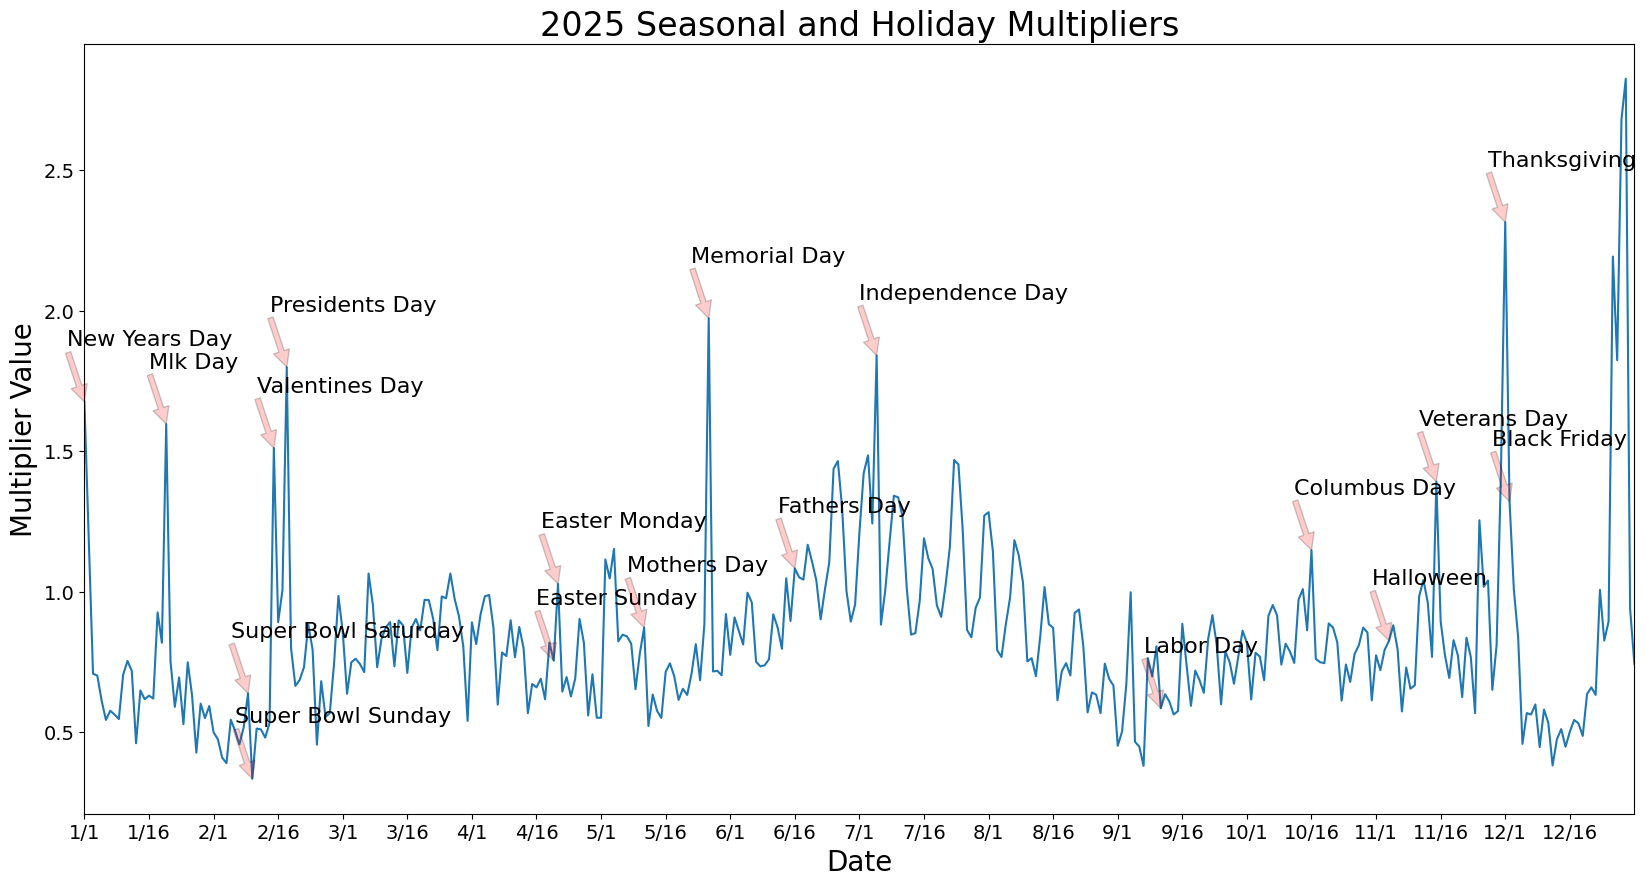

In [39]:
# loop through all days in 2025 and plot the day adjustment
from modeling.day_tags import get_adjustment_weight


start_date = dt.date(2025, 1, 1)
end_date = dt.date(2025, 12, 31)
day_adjustments = []
holiday_values: dict[dt.date, tuple[float, str]] = {} # dict from date to (value, tag)
current_date = start_date
while current_date < end_date:
    value = get_adjustment_weight(current_date)
    day_adjustments.append(value)
    tags = get_day_tags(current_date, tag_data.day_tags_dict)

    for tag in tags:
        tag_str = tag.name
        if current_date not in holiday_values:
            holiday_values[current_date] = (value, tag_str)
    current_date += dt.timedelta(days=1)

plt.figure(figsize=(20, 10))
plt.plot(day_adjustments)
plt.title("2025 Seasonal and Holiday Multipliers", fontsize=24)
plt.xlabel("Date", fontsize=20)
plt.ylabel("Multiplier Value", fontsize=20)
# 1st and 15th of each month for x axis
day_tick_range = [x for x in range(0, 360, 15)]
plt.xticks(
    day_tick_range,
    [f"{x // 30 + 1}/{x % 30 + 1}" for x in day_tick_range],
    fontsize=14,
)
plt.yticks(fontsize=14)
plt.xlim(0, 360)

# annotate the holidays on the graph
for date in holiday_values:
    # arrow to point
    text = holiday_values[date][1].replace("_", " ").title()
    if text in ["Thanksgiving Saturday", "Thanksgiving Sunday", "April Fools Day"]:
        continue
    if text == "Thanksgiving Day":
        text = "Thanksgiving"
    x_value = date.timetuple().tm_yday - 1
    y_value = holiday_values[date][0]
    plt.annotate(
        text,
        xy=(x_value, y_value),
        xytext=(x_value - 4, y_value + 0.2),
        arrowprops=dict(facecolor="red", shrink=0, alpha=0.2),
        fontsize=16,
    )
    
plt.show()

In [15]:
boxofficedays = supabase.rpc("sum_by_day", {
    "start_date": dt.date(2015, 1, 1).isoformat(),
    "end_date": dt.date(2025, 1, 1).isoformat(),
    "filter_x_days": 0,
}).execute().data

KeyboardInterrupt: 

Weekday 0:
Mean: 0.39640496003945175
Median: 0.33381879481877047
Std: 0.20167067367320876

Weekday 1:
Mean: 1.214495064536851
Median: 1.2874817650933308
Std: 0.3235075986187878

Weekday 2:
Mean: 0.7613691937539631
Median: 0.718741651652177
Std: 0.2413362222438925

Weekday 3:
Mean: 0.9747823370756367
Median: 0.9160766677316019
Std: 0.4761094699504538

Weekday 4:
Mean: 4.701741799997258
Median: 3.41980756638677
Std: 4.325416654240813

Weekday 5:
Mean: 1.411030368426704
Median: 1.3288120190643804
Std: 0.5662379112775835

Weekday 6:
Mean: 0.700986728274354
Median: 0.6807108983363519
Std: 0.14937896030666364



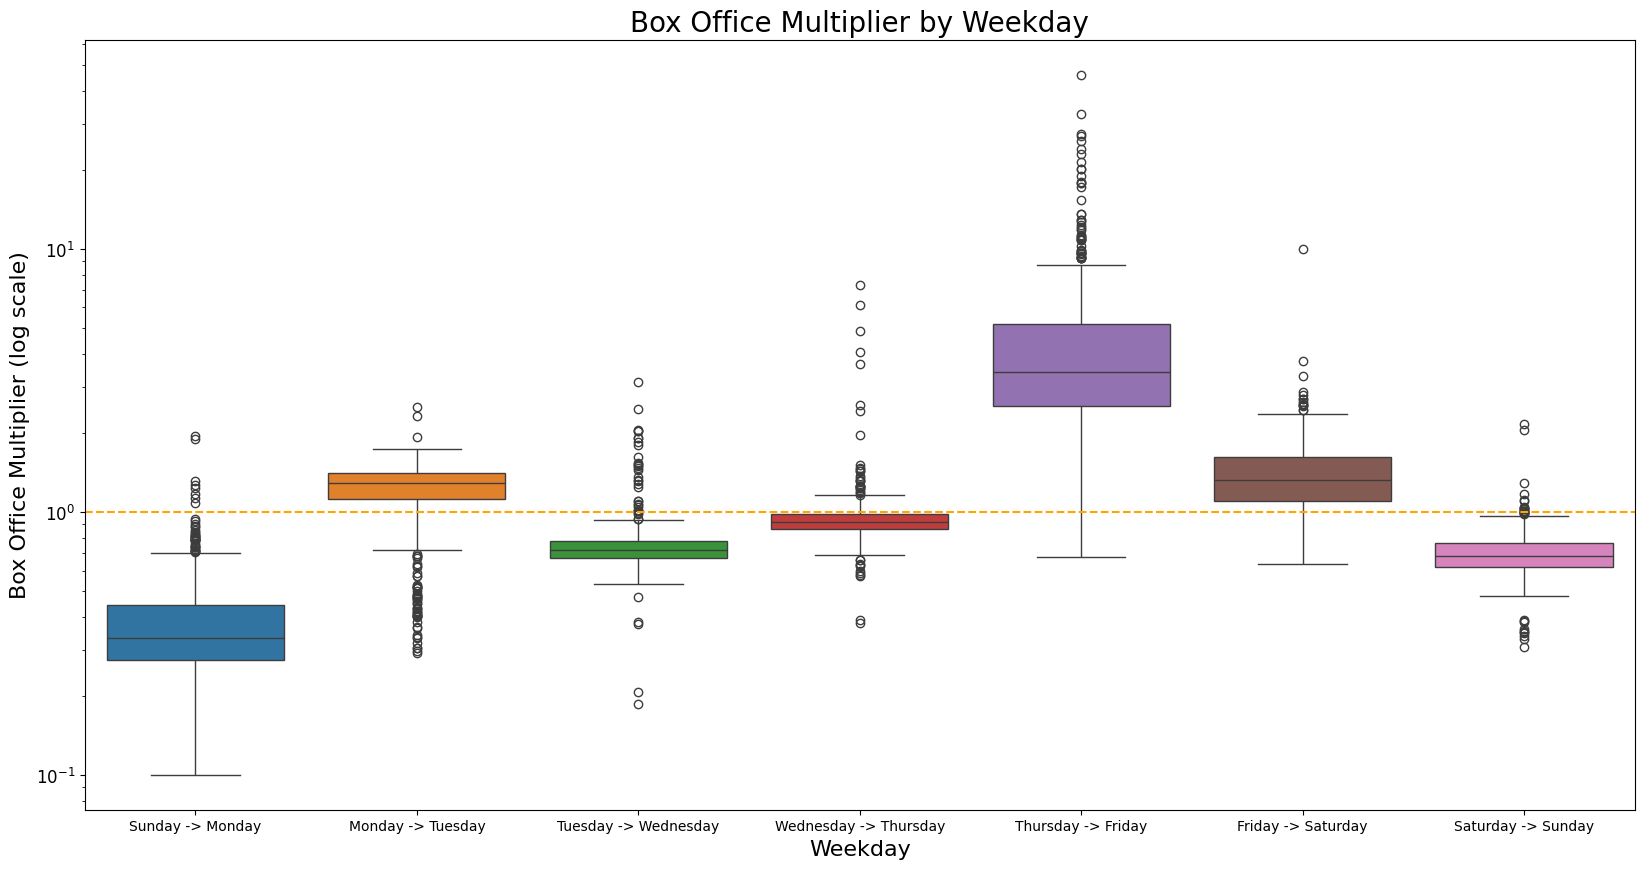

In [ ]:
weekday_mults: list[list[float] | None] = [None] * 7

previous = boxofficedays[0]["revenue"]
for day in boxofficedays[1:]:
    date = dt.datetime.strptime(day["date"], "%Y-%m-%d")
    weekday = date.weekday()
    if weekday_mults[weekday] is None:
        weekday_mults[weekday] = []
    if day["revenue"] > 100000 and previous > 100000:
        weekday_mults[weekday].append(day["revenue"] / previous)
    previous = day["revenue"]

# now print the median, mean, and std of each weekday
for i in range(7):
    print(f"Weekday {i}:")
    print(f"Mean: {np.mean(weekday_mults[i])}")
    print(f"Median: {np.median(weekday_mults[i])}")
    print(f"Std: {np.std(weekday_mults[i])}")
    print()

# create a box plot of the weekday mults
plt.figure(figsize=(20, 10))

data = {
    "Sunday -> Monday": weekday_mults[0],
    "Monday -> Tuesday": weekday_mults[1],
    "Tuesday -> Wednesday": weekday_mults[2],
    "Wednesday -> Thursday": weekday_mults[3],
    "Thursday -> Friday": weekday_mults[4],
    "Friday -> Saturday": weekday_mults[5],
    "Saturday -> Sunday": weekday_mults[6],
}

sns.boxplot(
    data=data,
)
plt.title("Box Office Multiplier by Weekday", fontsize=20)
plt.xlabel("Weekday", fontsize=16)
plt.ylabel("Box Office Multiplier (log scale)", fontsize=16)
plt.xticks([x for x in range(7)], ["Sunday -> Monday", "Monday -> Tuesday", "Tuesday -> Wednesday", "Wednesday -> Thursday", "Thursday -> Friday", "Friday -> Saturday", "Saturday -> Sunday"])
plt.yticks(fontsize=12)
plt.axhline(y=1, color="orange", linestyle="--")
# log scale the y axis
plt.yscale("log")
plt.show()